In [ ]:
#Уточните методом половинного деления наименьший по модулю и отличный от нуля корень уравнения xsinx-1=0 с точностью до 0.00001

In [1]:
# Уточнение корня уравнения x·sin(x) - 1 = 0 методом половинного деления
# Точность: 10^-4.Наименьший по модулю положительный корень (≈1.114)

# Импортируем необходимые библиотеки
from math import sin                 # синус (аргумент в радианах)
import numpy as np                   # для создания массива точек (linspace)
import matplotlib.pyplot as plt      # для построения графиков
import matplotlib.ticker as ticker   # для настройки делений на осях

In [ ]:
# Определение функции, корни которой ищем
def f(x):
    """Исходная функция: f(x) = x*sin(x) - 1. Её нули – корни уравнения."""
    return x * sin(x) - 1

In [ ]:
# Вспомогательные функции для построения графиков левой и правой частей
# Уравнение x·sin(x) = 1 можно представить как пересечение y1 = x·sin(x) и y2 = 1

def y1(x):
    """Левая часть: y = x·sin(x)"""
    return x * sin(x)

def y2(x):
    """Правая часть: y = 1 (константа)"""
    return 1

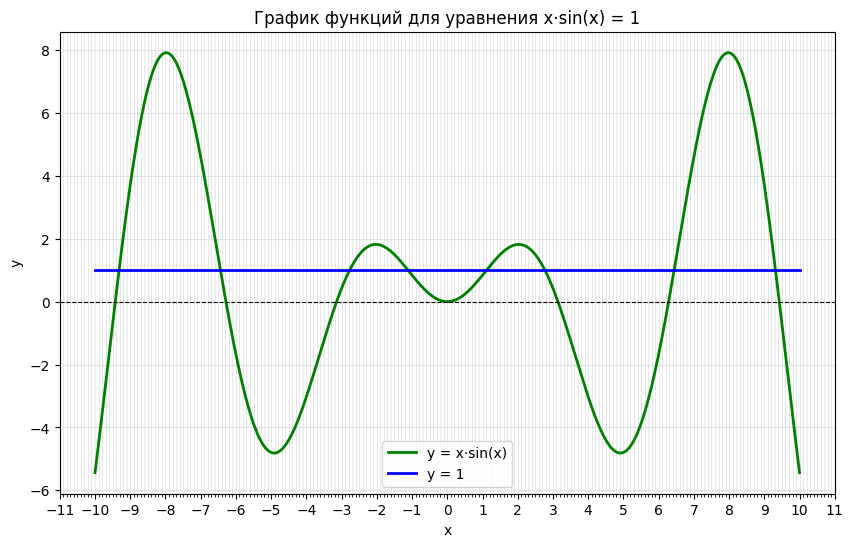

In [ ]:
# Построение графиков для визуального отделения корней
# Создаём массив x от -10 до 10 с шагом (500 точек) – достаточно для гладкого графика
x_vals = np.linspace(-10, 10, 500)
# Вычисляем значения функций в этих точках
y1_vals = [y1(x) for x in x_vals]
y2_vals = [y2(x) for x in x_vals]

# Создаём фигуру и оси
fig, ax = plt.subplots(figsize=(10, 6))
# Рисуем графики: зелёный – y = x·sin(x), синий – y = 1
ax.plot(x_vals, y1_vals, color='green', linewidth=2, label='y = x·sin(x)')
ax.plot(x_vals, y2_vals, color='blue', linewidth=2, label='y = 1')

# Настройка сетки и подписей
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))    # основные деления по x через 1
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))  # дополнительные через 0.1
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)  # линия y=0 для ориентира
ax.grid(True, which='both', alpha=0.3)                   # включаем сетку
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('График функций для уравнения x·sin(x) = 1')
ax.legend()


In [5]:
# Численное отделение корней: поиск интервалов, где f(x) меняет знак
# Проходим по x от -10 до 10 с шагом 0.1. Если на отрезке [x, x+step], произведение f(x)*f(x+step) < 0, значит внутри есть корень.

intervals = []          # список для хранения интервалов (a, b)
step = 0.1              # шаг перебора
x = -10                 # начальная точка

while x < 10:           # пока не дошли до правого края
    if f(x) * f(x + step) < 0:      # знаки разные, згачит корень есть
        intervals.append((x, x + step))   # добавляем интервал
    x += step

In [6]:
# Уточнение корней на каждом найденном интервале методом половинного деления
# Точность eps = 1e-4 (10⁻⁴)
eps = 1e-4              # заданная точность
roots = []              # список для уточнённых корней

for interval in intervals:                # перебираем все интервалы
    x1, x2 = interval                     # левая и правая границы
    # Половинное деление до тех пор, пока длина интервала не станет ≤ eps
    while abs(x2 - x1) > eps:
        c = (x1 + x2) / 2                 # середина отрезка
        if f(x1) * f(c) <= 0:            # корень в левой половине
            x2 = c
        else:                             # корень в правой половине
            x1 = c
    root = (x1 + x2) / 2                 # финальное приближение
    roots.append(root)                   # сохраняем


In [7]:
# Отмечаем найденные корни на графике красными точками
y_roots = [y1(r) for r in roots]         # значения y = x·sin(x) в точках корней
ax.plot(roots, y_roots, 'ro', markersize=6, label='Корни')
ax.legend()                              # обновляем легенду


In [9]:
# Вывод результатов на экран
print(f"Уточнение корней уравнения x·sin(x) - 1 = 0 методом половинного деления")
print(f"Точность: {eps}")

for i in range(len(intervals)):
    print(f"Интервал {i+1}: {intervals[i]}, корень = {roots[i]:.6f}")

Уточнение корней уравнения x·sin(x) - 1 = 0 методом половинного деления
Точность: 0.0001
Интервал 1: (-9.400000000000002, -9.300000000000002), корень = -9.317236
Интервал 2: (-6.500000000000012, -6.400000000000013), корень = -6.439111
Интервал 3: (-2.8000000000000203, -2.70000000000002), корень = -2.772607
Интервал 4: (-1.2000000000000188, -1.1000000000000187), корень = -1.114111
Интервал 5: (1.0999999999999812, 1.1999999999999813), корень = 1.114111
Интервал 6: (2.6999999999999824, 2.7999999999999825), корень = 2.772607
Интервал 7: (6.3999999999999755, 6.499999999999975), корень = 6.439111
Интервал 8: (9.299999999999965, 9.399999999999965), корень = 9.317236


In [10]:
# Находим наименьший по модулю отличный от нуля корень
# Из всех полученных корней выбираем тот, у которого абсолютное значение минимально,
# но не равное нулю (нулевого корня нет в нашем списке, т.к. f(0) = -1 ≠ 0).
min_abs_root = min(roots, key=abs)       # корень с минимальным модулем
print(f"Наименьший по модулю корень: {min_abs_root:.6f}")

# Показываем график
plt.show()

Наименьший по модулю корень: 1.114111
